Collisions of 2 bright solitons in 1d

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [16]:
L, N = 40.0, 1024
dx = L / N
x = np.linspace(-L/2, L/2, N, endpoint=False)
k = 2 * np.pi * fftfreq(N, d=dx)
dt = 0.01
kappa1 = -1.0

In [17]:
# 1st soliton (from left to right)
A1, v1, x1 = 2.0, 3.0, -5.0
psi1 = (A1 / np.cosh(A1 * (x - x1))) * np.exp(1j * v1 * x)

# 2nd solitons (from right to left)
A2, v2, x2 = 2.2, -3.0, 5.0
psi2 = (A2 / np.cosh(A2 * (x - x2))) * np.exp(1j * v2 * x)

psi = (psi1 + psi2).astype(complex)
psi_init = psi.copy()

In [18]:
times, densities, energies = [], [], []

def get_stats(p, k_vec, dx_val, kappa):
    dens = np.sum(np.abs(p)**2) * dx_val
    p_hat = fft(p)
    d_psi = ifft(1j * k_vec * p_hat)
    ener = np.sum(0.5 * np.abs(d_psi)**2 + 0.5 * kappa * np.abs(p)**4) * dx_val
    return dens, ener

Text(0, 0.5, '$|\\psi|^2$')

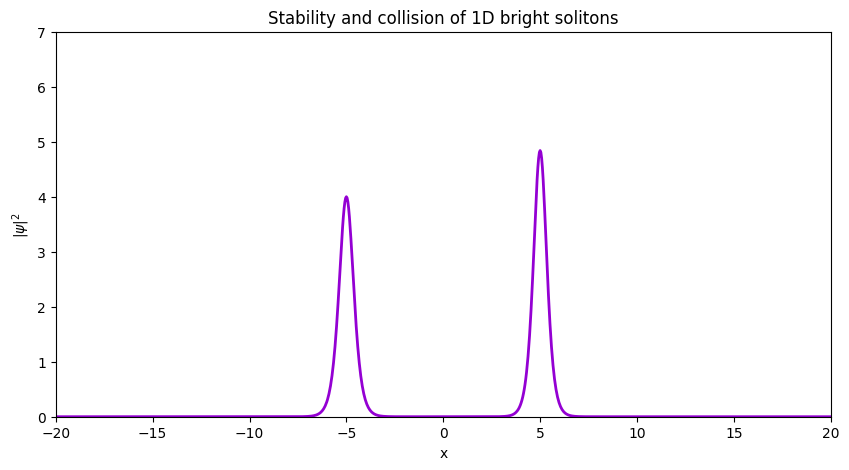

In [19]:

fig, ax = plt.subplots(figsize=(10, 5))
line, = ax.plot(x, np.abs(psi)**2, color='darkviolet', lw=2)
time_text = ax.text(0.05, 0.9, '', transform=ax.transAxes)
ax.set_xlim(-L/2, L/2)
ax.set_ylim(0, 7) 
ax.set_title("Stability and collision of 1D bright solitons")
ax.set_xlabel("x")
ax.set_ylabel(r"$|\psi|^2$")

In [20]:
def update(frame):
    global psi
    #TSSP
    for _ in range(8): 
        psi *= np.exp(-0.5j * kappa1 * np.abs(psi)**2 * dt)
        p_hat = fft(psi)
        p_hat *= np.exp(-0.5j * k**2 * dt)
        psi = ifft(p_hat)
        psi *= np.exp(-0.5j * (kappa1 * np.abs(psi)**2) * dt)
    
    d, e = get_stats(psi, k, dx, kappa1)
    densities.append(d)
    energies.append(e)
    times.append(frame * dt * 8)

    line.set_ydata(np.abs(psi)**2)
    time_text.set_text(f'Time: {frame * dt * 8:.2f}')
    return line, time_text

ani = FuncAnimation(fig, update, frames=50, blit=True, interval=30)

ani.save("bright_solitons_1d/bs1d.html", writer='html')

plt.close()


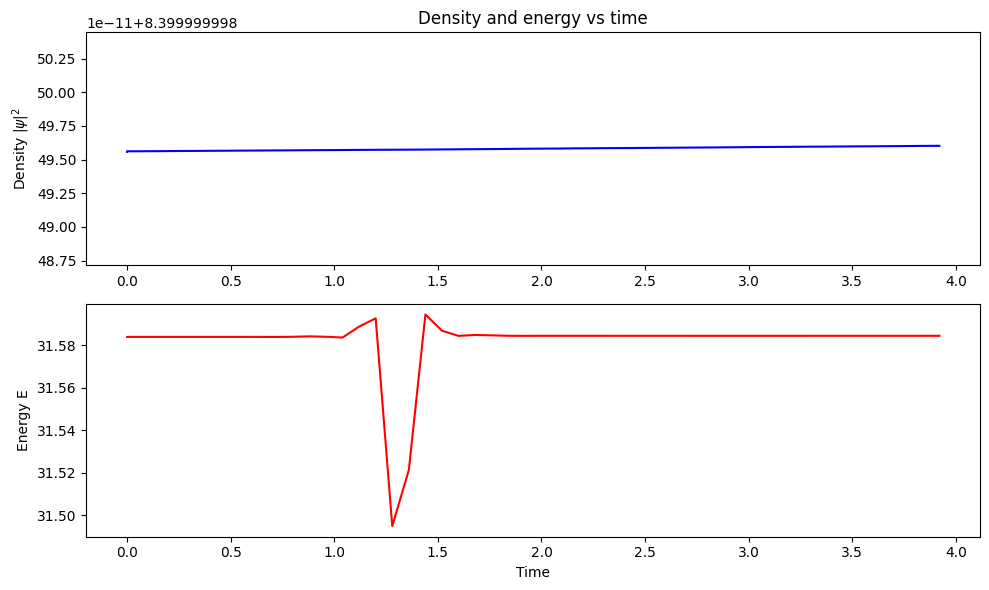

In [21]:
fig_stats, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
ax1.plot(times, densities, 'b'); ax1.set_ylabel(r"Density $|\psi|^2$")
ax1.set_title("Density and energy vs time")
ax2.plot(times, energies, 'r'); ax2.set_ylabel("Energy E")
ax2.set_xlabel("Time")
plt.tight_layout()
plt.savefig("bright_solitons_1d/te_bs1d.pdf")
plt.show()